# Does the number of hospitalizations depend on the average age of the people living in the nearest cities?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify  # pip install squarify
import plotly.express as px
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from patsy import cr
import plotly.graph_objects as go

Load the datasets and merge them to create a final dataset containing the average age of the population in the catchment area of each hospital and the number of hospitalizations at that hospital.

In [2]:

# load cities_with_all_data and nemocnice_kompletni
cities_df = pd.read_csv('../data/cities_with_all_data.csv')
hospitals_df = pd.read_csv('../data/nemocnice_kompletni.csv')

cities_df['age_weighted'] = cities_df['Prumerny_vek_celkem'] * cities_df['Total']
catchment_stats = cities_df.groupby('Nejblizsi_nemocnice')[['Total', 'age_weighted']].sum().reset_index()
catchment_stats['catchment_avg_age'] = catchment_stats['age_weighted'] / catchment_stats['Total']

# create second dataset with leave out data with avg age < 20 and > 80
catchment_stats = catchment_stats[
    (catchment_stats['catchment_avg_age'] >= 1) & (catchment_stats['catchment_avg_age'] <= 100)
]

hospitals_clean = hospitals_df.copy()
hospitals_clean['Pocet_hospitalizaci'] = pd.to_numeric(hospitals_clean['Pocet_hospitalizaci'], errors='coerce')

final_df = pd.merge(catchment_stats, hospitals_clean, left_on='Nejblizsi_nemocnice', right_on='Nazev')
final_df = final_df.dropna(subset=['Pocet_hospitalizaci'])
final_df['hospitalization_rate'] = final_df['Pocet_hospitalizaci'] / final_df['Total'] # hospitalization rate is defined as number of hospitalizations divided by total population in catchment area
# Thresholding to remove extreme outliers
threshold = final_df['hospitalization_rate'].quantile(0.9)
final_df = final_df[final_df['hospitalization_rate'] < threshold]




Plot data with basic regression line from seaborn to get basic idea of the trend.

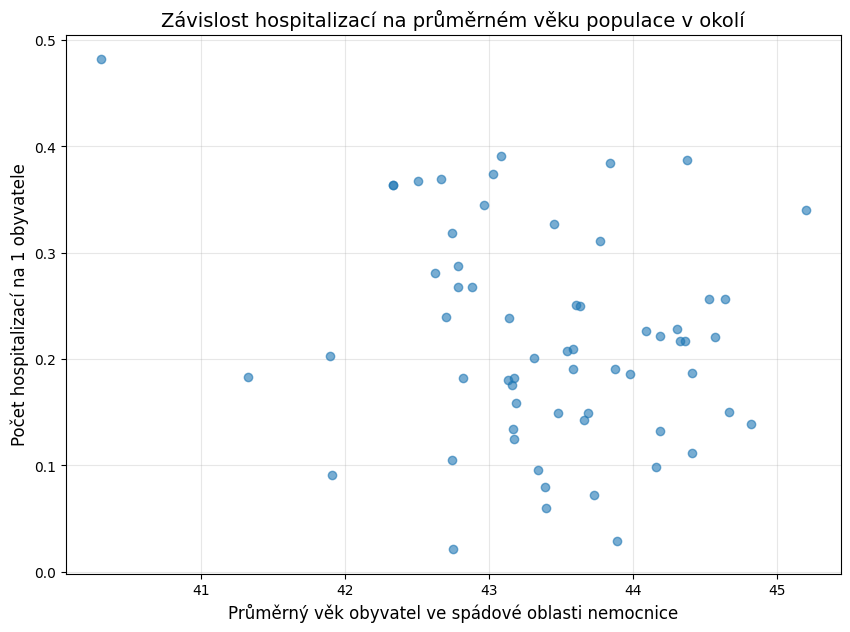

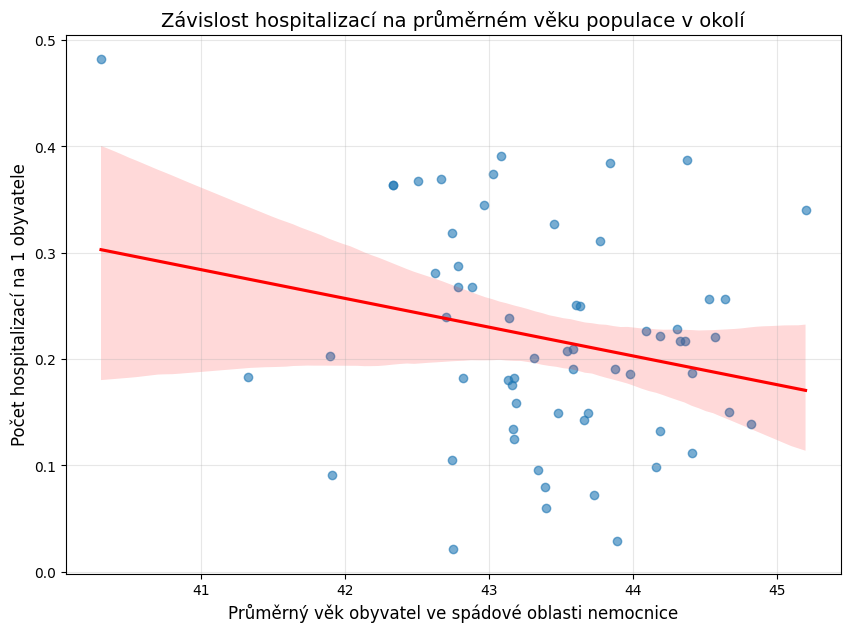

In [3]:
plt.figure(figsize=(10, 7))
plt.plot(final_df['catchment_avg_age'],
         final_df['hospitalization_rate'], 'o', alpha=0.6)
plt.title('Závislost hospitalizací na průměrném věku populace v okolí', fontsize=14)
plt.xlabel('Průměrný věk obyvatel ve spádové oblasti nemocnice', fontsize=12)
plt.ylabel('Počet hospitalizací na 1 obyvatele', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 7))
sns.regplot(
    x='catchment_avg_age',
    y='hospitalization_rate',
    data=final_df,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title('Závislost hospitalizací na průměrném věku populace v okolí', fontsize=14)
plt.xlabel('Průměrný věk obyvatel ve spádové oblasti nemocnice', fontsize=12)
plt.ylabel('Počet hospitalizací na 1 obyvatele', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Get some insight from the correlation coefficient between the two variables.

In [4]:

corr = final_df['catchment_avg_age'].corr(final_df['hospitalization_rate'])
print(f"Korelační koeficient: {corr:.4f}")

# perform generalized linear model fit

Korelační koeficient: -0.2352


Lets begin with linear regression model.

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
import matplotlib.pyplot as plt

TEST LINEARITY


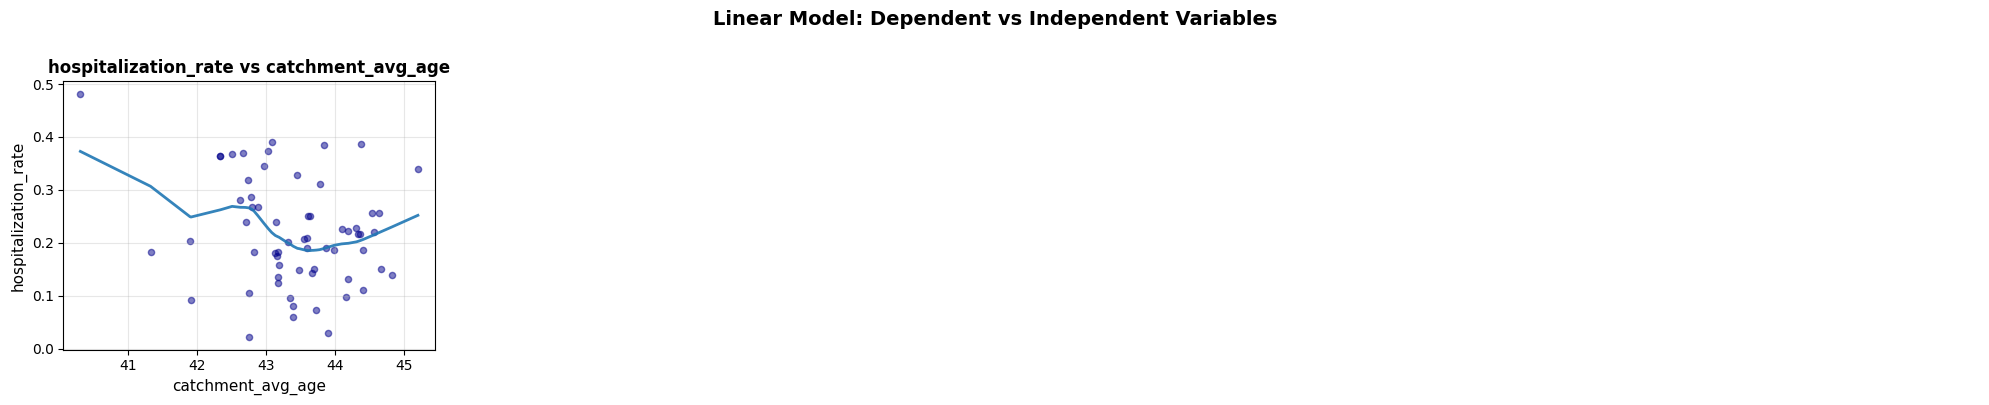

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



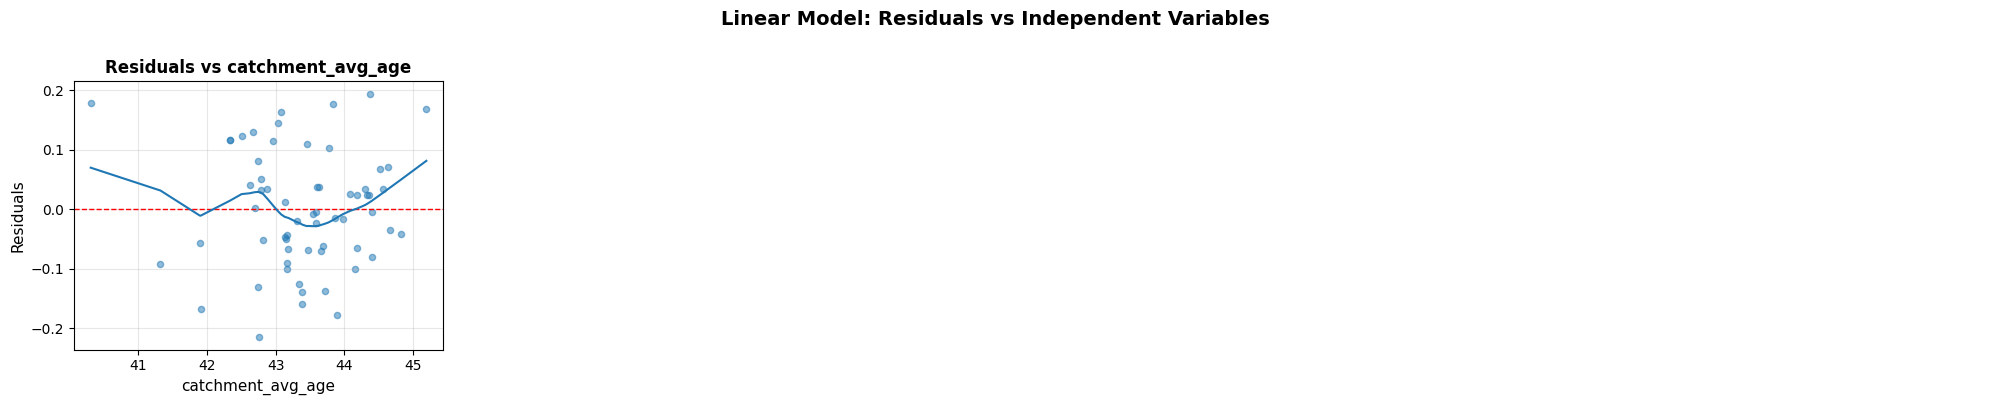

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Linear Model: 0.2043 (LM stat=3.176)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Linear Model: 1.728
Ljung–Box test results for Linear Model (lags [10, 20, 40]):
      lb_stat  lb_pvalue
10   3.583953   0.964171
20  11.820770   0.922107
40  29.351313   0.892515


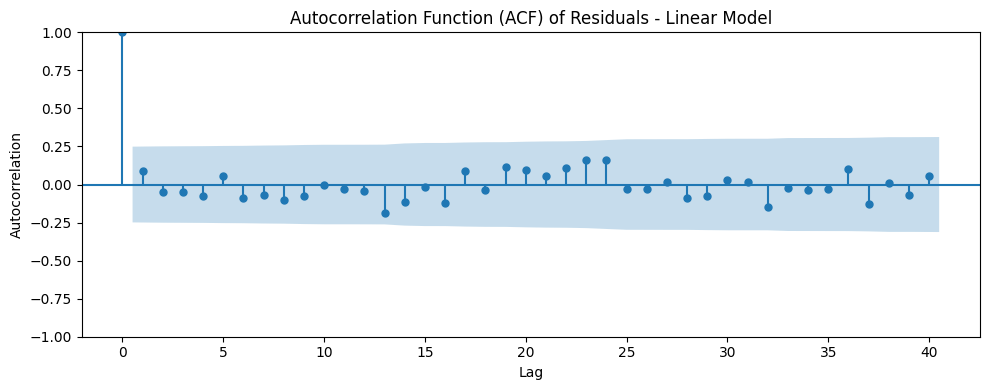

------------------------------------------------
TEST NORMALITY OF ERRORS


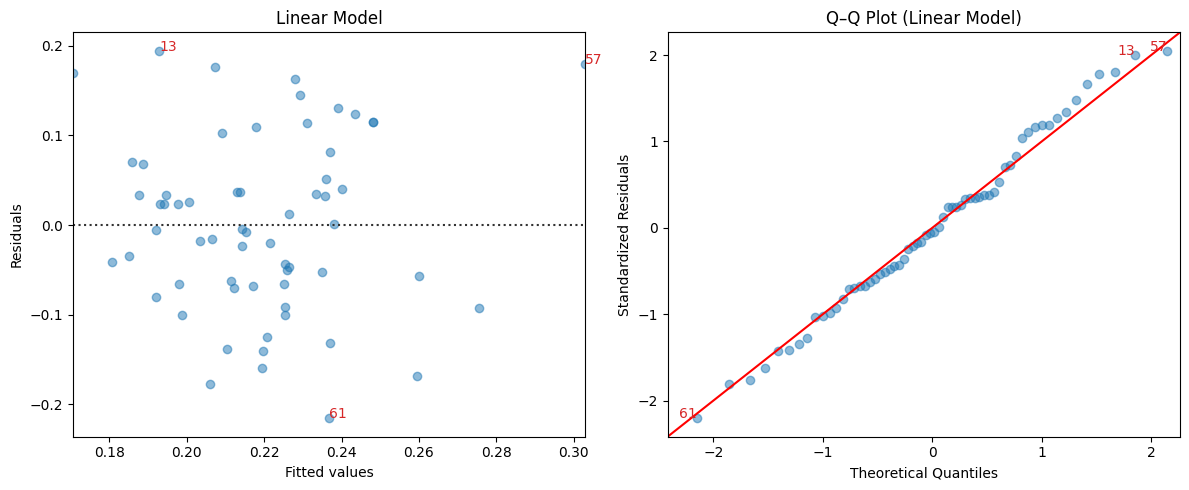

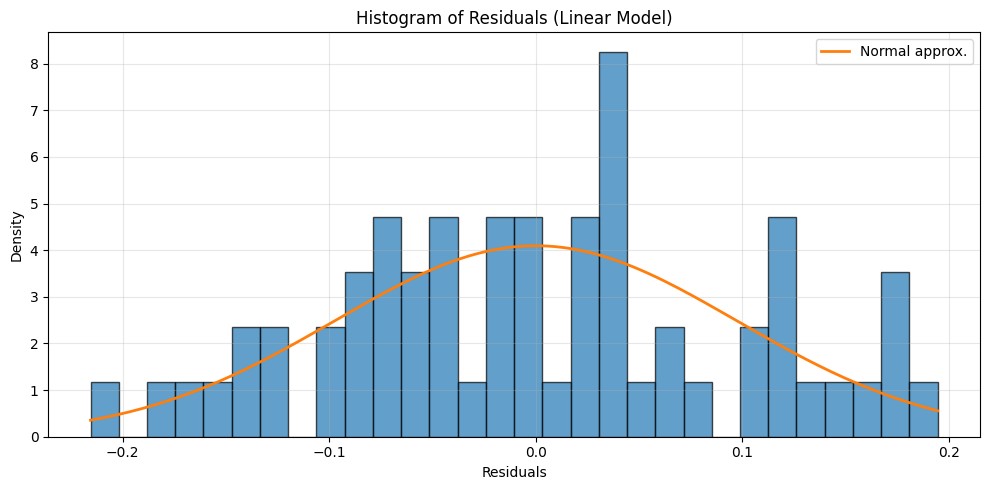

Shapiro–Wilk test for Linear Model: W=0.9841, p-value=0.6034
------------------------------------------------
TEST MULTICOLLINEARITY


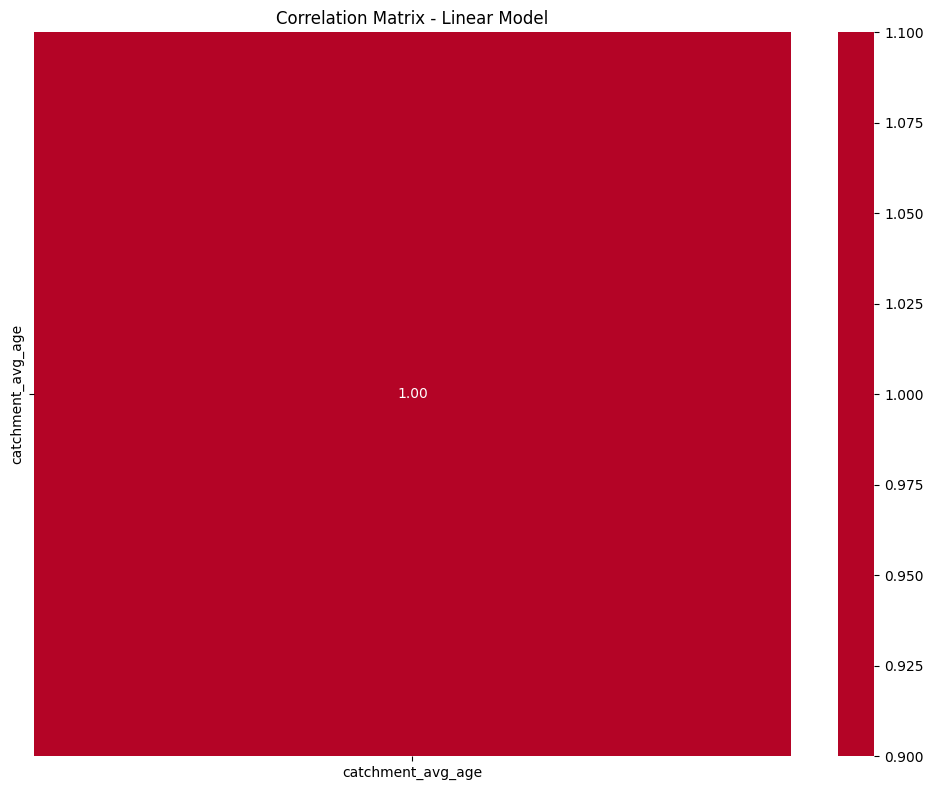

Variance Inflation Factor (VIF):
            Features  VIF Factor
1  catchment_avg_age        1.00
0          Intercept     2488.38
------------------------------------------------


In [6]:
from lin_reg_utils import perform_all_tests

# perform_all_tests očekává features jako seznam
model = smf.ols('hospitalization_rate ~ catchment_avg_age', data=final_df).fit()

perform_all_tests(model, final_df, [
                  'catchment_avg_age'], 'Linear Model', y_col='hospitalization_rate')

Looking at assumptions, we see that the model violates some of them:
1) Linearity - <span style="color:Orange;">Questionable</span>
    - there might be a non-linear relationship between the average age and hospitalization rate
2) Independence of errors - <span style="color:green;">Holds</span> 
    - based on Durbin-Watson test, Ljung-Box test and ACF plot of residuals we can say that there is no autocorrelation (Durbin-Watson is 1.728, Ljung-Box p-values are all higly above 0.05)
3) Normality of residuals - <span style="color:green;">Holds</span>
    - based on Q-Q plot, histogram and Shapiro-Wilk test we can say that the residuals are now normally distributed (Shapiro-Wilk p-value is 0.6034)
4) Homoscedacity - <span style="color:green;">Holds</span>
    - based on Breusch-Pagan test we can say that there is Homoscedacity (p-value is 0.2043 > 0.05)
5) Absence of multicollinearity - <span style="color:Green;">Holds</span>
    - there is only one feature in the model so there is no multicollinearity

                             OLS Regression Results                             
Dep. Variable:     hospitalization_rate   R-squared:                       0.055
Model:                              OLS   Adj. R-squared:                  0.040
Method:                   Least Squares   F-statistic:                     3.513
Date:                  Wed, 03 Dec 2025   Prob (F-statistic):             0.0658
Time:                          17:57:22   Log-Likelihood:                 56.430
No. Observations:                    62   AIC:                            -108.9
Df Residuals:                        60   BIC:                            -104.6
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         

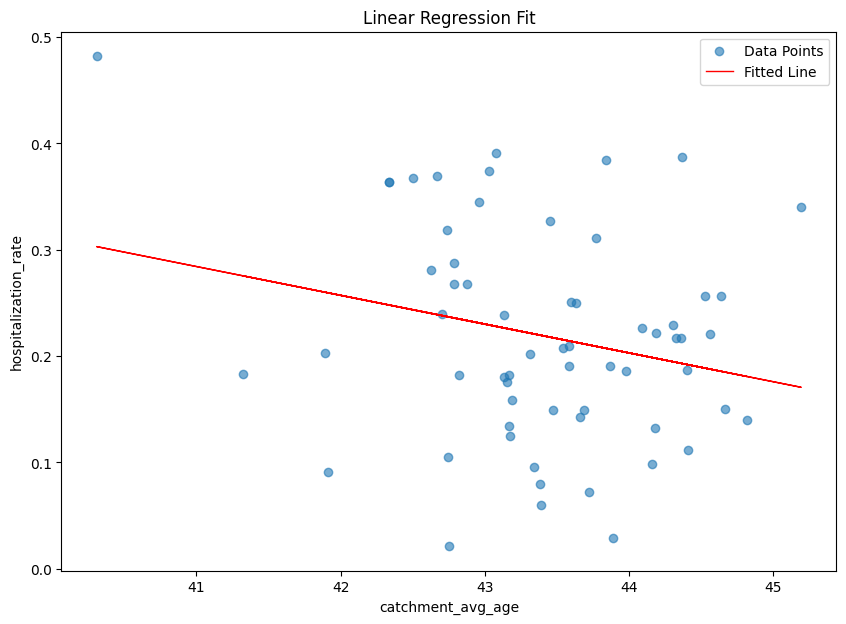

In [7]:
print(model.summary())

#plot the model
plt.figure(figsize=(10, 7))
plt.scatter(final_df['catchment_avg_age'], final_df['hospitalization_rate'], alpha=0.6, label='Data Points')
plt.plot(final_df['catchment_avg_age'], model.fittedvalues, color='red', linewidth=1, label='Fitted Line')
plt.title('Linear Regression Fit')
plt.xlabel('catchment_avg_age')
plt.ylabel('hospitalization_rate')
plt.legend()
plt.show()

#### Regression model results

The model satisfies most of the assumptions of linear regression (we can discuss the linearity assumption "only"). 
The model explains only about 5.5% of the variance in hospitalization rates (R-squared = 0.055) which indicates that there are likely other factors influencing hospitalization rates beyond just the average age of the population in the catchment area and there might be some confounding variables affecting the relationship. 

The intercept of the model is 1.3943 which say that for populations with an average age of 0 (which is not realistic), the hospitalization rate would be 1.3943 per one person. Intrestingly the coefficient for catchment_avg_age is -0.0271 indicating that for each additional year in average age, the hospitalization rate decreases by 0.0271 per one person. This is counterintuitive as we would expect older populations to have higher hospitalization rates. This suggests that there may be other confounding variables affecting the relationship between average age and hospitalization rate that are not accounted for in this model. Further investigation is needed to understand this relationship better.


Lets try some more complex models - polynomial regression and decision tree regression.

We will try poisson family for GLM as hospitalization counts are count data. To have rate instead of counts we will use offset for population size. We will use np.log(final_df['Total']) as offset in the model.
This is because:
- ```ln(y) = Xβ + ln(population)```
- ```Rate = Num_of_hospitalizations(Y)/Total(N)```
- In GLM with log link function: ```Y = N*exp(Xβ)```
- ```ln(Y) = ln(N) + Xβ```
- Thus we include ln(N) as an offset in the model to account for population size when modeling hospitalization counts.

To find best ```alpha``` for Negative Binomial model, we can use cross-validation where the criterion is the log-likelihood of the model on the validation set. We can try a range of alpha values and select the one that maximizes the average log-likelihood across the folds.

Lets first check overdispersion if overdispersion is present, we will use Negative Binomial model instead of Poisson.

In [8]:
model_null = sm.GLM(
    final_df['Pocet_hospitalizaci'],
    np.ones((len(final_df), 1)),  # Pouze konstanta
    family=sm.families.Poisson(),
    offset=np.log(final_df['Total'])
).fit()

dispersion_stat = model_null.pearson_chi2 / model_null.df_resid
print(f"Corrected Dispersion Statistic: {dispersion_stat:.2f}")
if dispersion_stat > 1.5:
    print("Overdispersion detected. Using Negative Binomial model.")

Corrected Dispersion Statistic: 5094.67
Overdispersion detected. Using Negative Binomial model.


We have overdispersion detected. So we will use Negative Binomial model and we will find optimal alpha using cross-validation.

Finding optimal alpha using 10-fold cross-validation...


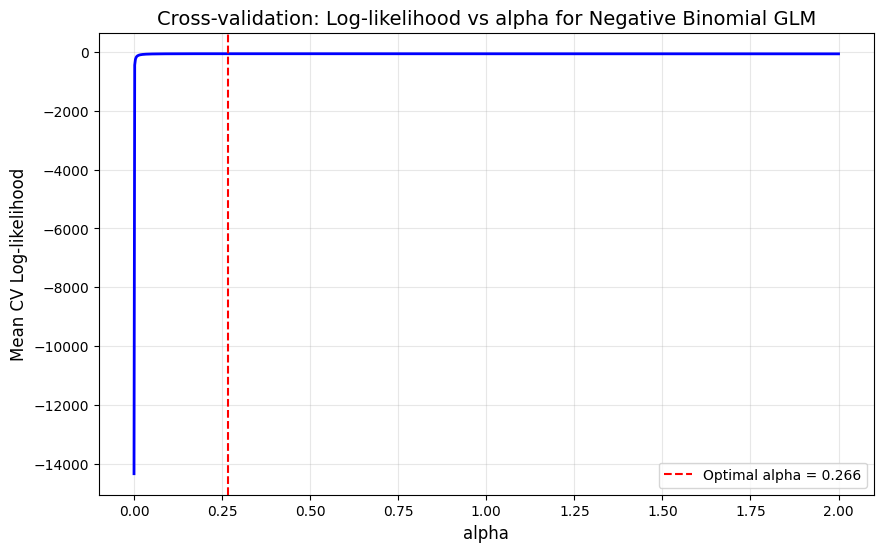

Optimal alpha (via CV): 0.266275
Best mean CV log-likelihood: -64.234


In [9]:
#find best alpha for negative binomial model
from sklearn.model_selection import KFold
alphas = np.linspace(0.00001, 2, 1000)
cv_scores = []

X_np = sm.add_constant(final_df['catchment_avg_age'])
X_np = X_np.values
y_np = final_df['Pocet_hospitalizaci'].values 
offset_np = np.log(final_df['Total'].values) 

print("Finding optimal alpha using 10-fold cross-validation...")
for a in alphas:
    skf = KFold(n_splits=10, shuffle=True, random_state=0)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_np, y_np):
        model = sm.GLM(endog=y_np[train_idx], exog=X_np[train_idx],
                       family=sm.families.NegativeBinomial(alpha=a),
                       offset=offset_np[train_idx])  # přidáme offset
        fit = model.fit()
        predictions = fit.predict(X_np[val_idx], offset=offset_np[val_idx])
        predictions = np.where(predictions <= 0, 1e-10, predictions)
        ll = fit.family.loglike_obs(endog=y_np[val_idx], mu=predictions).sum()
        fold_scores.append(ll)

    cv_scores.append(np.mean(fold_scores))

plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_scores, 'b-', linewidth=2)
plt.xlabel("alpha", fontsize=12)
plt.ylabel("Mean CV Log-likelihood", fontsize=12)
plt.title(
    "Cross-validation: Log-likelihood vs alpha for Negative Binomial GLM", fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(alphas[np.argmax(cv_scores)], color='r', linestyle='--',
            label=f'Optimal alpha = {alphas[np.argmax(cv_scores)]:.3f}')
plt.legend()
plt.show()

optimal_alpha = alphas[np.argmax(cv_scores)]
print(f"Optimal alpha (via CV): {optimal_alpha:.6f}")
print(f"Best mean CV log-likelihood: {np.max(cv_scores):.3f}")

Optimal alpha found is close to 0 which is equivalent to Poisson regression and in the data there is no overdispersion.

In [10]:
# Poisson GLM s offsetem (pro count data)
"""
model_poisson = sm.GLM(
    final_df['Pocet_hospitalizaci'],  # závislá proměnná jako počet
    sm.add_constant(final_df['catchment_avg_age']),
    family=sm.families.Poisson(),
    offset=np.log(final_df['Total'])  # offset pro velikost populace -> prevede to na rate
).fit()

final_df['hospitalization_rate_poisson'] = model_poisson.fittedvalues / \
    final_df['Total']  # predicted rate
"""

# Negative Binomial GLM s offsetem (pro count data s overdispersion)
model_nb = sm.GLM(
    final_df['Pocet_hospitalizaci'],  # závislá proměnná jako počet
    sm.add_constant(final_df['catchment_avg_age']),
    family=sm.families.NegativeBinomial(alpha=optimal_alpha),
    offset=np.log(final_df['Total']),  # offset pro velikost populace
).fit()
final_df['hospitalization_rate_nb'] = model_nb.fittedvalues / \
    final_df['Total']  # predicted rate
    

Lets check overdispersion.

Plots

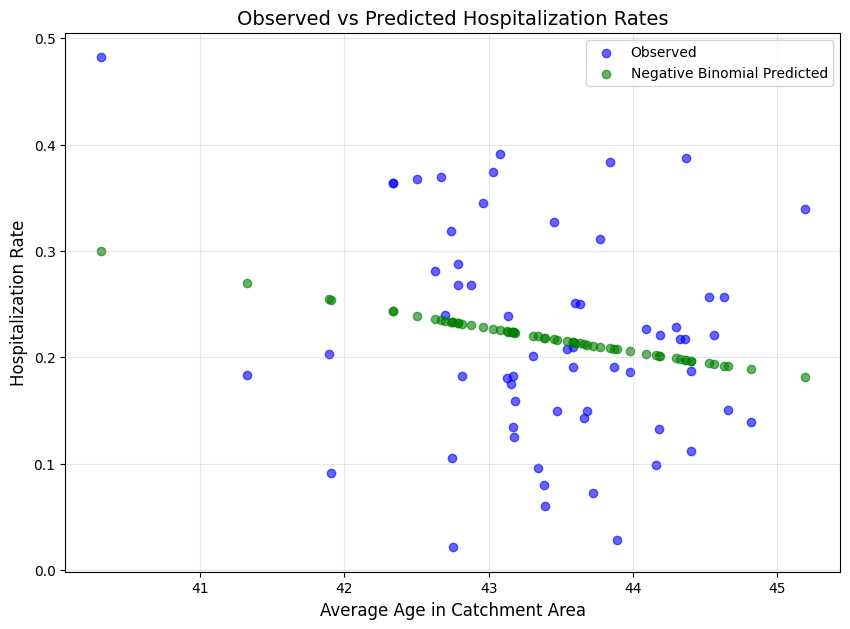

In [11]:
plt.figure(figsize=(10, 7))
plt.scatter(final_df['catchment_avg_age'], final_df['hospitalization_rate'],
            alpha=0.6, label='Observed', color='blue')
#plt.scatter(final_df['catchment_avg_age'], final_df['hospitalization_rate_poisson'],
#            alpha=0.6, label='Poisson Predicted', color='orange')
plt.scatter(final_df['catchment_avg_age'], final_df['hospitalization_rate_nb'],
            alpha=0.6, label='Negative Binomial Predicted', color='green')
plt.title('Observed vs Predicted Hospitalization Rates', fontsize=14)
plt.xlabel('Average Age in Catchment Area', fontsize=12)
plt.ylabel('Hospitalization Rate', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [12]:
print(model_nb.summary())

                  Generalized Linear Model Regression Results                  
Dep. Variable:     Pocet_hospitalizaci   No. Observations:                   62
Model:                             GLM   Df Residuals:                       60
Model Family:         NegativeBinomial   Df Model:                            1
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -640.94
Date:                 Wed, 03 Dec 2025   Deviance:                       61.794
Time:                         17:57:26   Pearson chi2:                     44.8
No. Iterations:                      7   Pseudo R-squ. (CS):            0.03494
Covariance Type:             nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.9242

### Poisson model with offset 

By observing the plot, we can see that the Poisson model tends to fit the data better than the linear regression model. However both models seems to have similar performance in predicting hospitalization rates based on average age in the catchment area. Pseudo R-squared for Poisson model is 0.03494. Log-likelihood: -640 suggests that the model is not a very good fit for the data.
We suppose that the reason for this is that there might be some other confounding variables affecting the relationship between average age and hospitalization rates that are not accounted for in this model.

### Conclusion
***Does the number of hospitalizations in a hospital depend on the average age of the surrounding of the hospital?***

Not really.
The correlation coefficient is very low, indicating a weak relationship between the average age of the population in the hospital's catchment area and the hospitalization rate.